In [19]:
import logging

import numpy as np
import matplotlib.pyplot as plt 
from argparse import Namespace

from var_assim.emis import EmissionsBaseline
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing
from var_assim.config import DATA_DIR_ABS, PRIOR_PATH, NOISE_PATH, WINDOW_PATH, TRUTH_PATH, FIGS_DIR

# enable auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)-8s | %(message)s",
                    datefmt="%H:%M:%S")

logs = logging.getLogger('notebook')
logs.info("made!")

14:59:40 | INFO     | made!


In [21]:
experimental_setup = {
    'model': 'pco2geowc_reg_noic',
    'scenario': 'ssp245',
    'noise_model': 'AR1',
    'tmin': 2025,
    'theta': 15,
    'AR': '1',
    'ecs': 3.0,
    'deg_p_dec': 0.1,
    'nyrsramp': 50,
    'n_ens': 1,
    'reg_noise': True,
    'windowing': 'gradual',
    'sai_ramp': 'linear'
}

setup = Namespace(**experimental_setup)

In [ ]:
# setup data classes
Noise = ClimateModelNoise.from_cli_and_yaml(setup, NOISE_PATH)
Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(setup, PRIOR_PATH, Noise)
Windowing = AssimilationWindowing.from_cli_and_yaml(setup, WINDOW_PATH)
Truth = ClimateModelTruth.from_cli_and_yaml(setup, TRUTH_PATH)

# setup emissions
tmin_ws = 1850
e_ws = EmissionsBaseline(logs, setup, tmin_ws, setup.tmin,
                      geo=False, Prior=Prior, Truth=Truth,
                      T_START=setup.tmin, T_END=setup.tmin + setup.nyrsramp,
                      print_level=1)

15:10:52 | INFO     |     > Emissions baseline for ssp245 created
15:10:53 | INFO     |     > Emissions baseline for ssp245 created


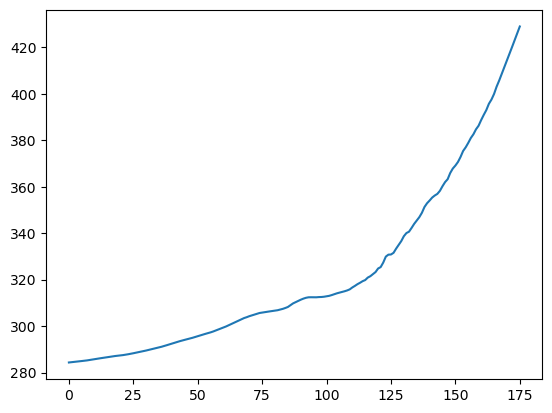

In [59]:
plt.plot(e_ws.conc['CO2'])

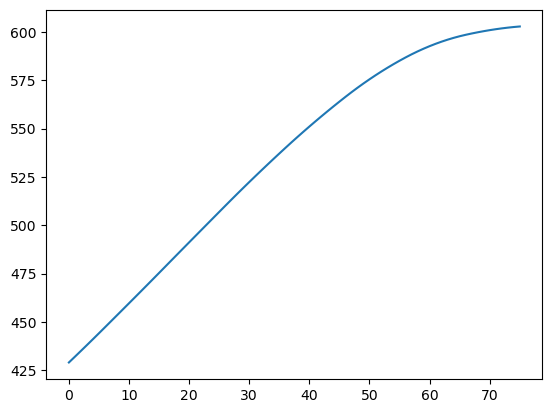

In [60]:
plt.plot(e.conc['CO2'])

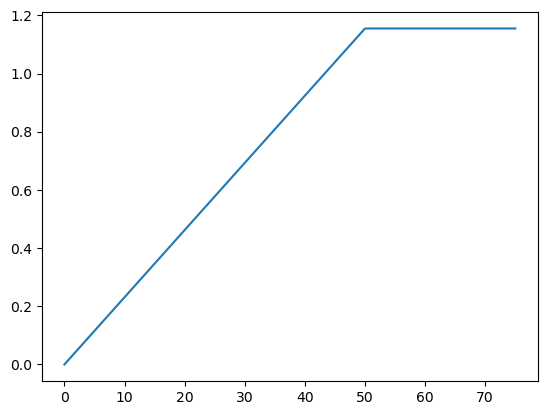

In [61]:
plt.plot(e.emis['geo'] * 0.09)

In [62]:
def integrate_two_layer(e, Prior, tmin, tmax, T_ics=[0, 0], dt=1):
    times = np.arange(tmin, tmax, dt)

    T = np.zeros((2, len(times)))
    T[:, 0] = T_ics

    for t in range(1, len(times)):
        T1_prev, T2_prev = T[:, t-1]

        if e.geo:
            T[0, t] = T1_prev + (dt / Prior.C1_CEN) * (Prior.F1_CO2_CEN * np.log(e.conc['CO2'][t-1]/278.3) - 0.09 * e.emis['geo'][t-1] 
                    - Prior.L_CEN * T1_prev + Prior.G_CEN * Prior.ECS_CEN * (T2_prev - T1_prev))

        else:
            T[0, t] = T1_prev + (dt / Prior.C1_CEN) * (Prior.F1_CO2_CEN * np.log(e.conc['CO2'][t-1]/278.3)
                                                       \
                    - Prior.L_CEN * T1_prev + Prior.G_CEN * Prior.ECS_CEN * (T2_prev - T1_prev))
        T[1, t] = T2_prev + (dt / Prior.C2_CEN) * Prior.G_CEN * (T1_prev - T2_prev)

    return T

In [ ]:
dt = 1.0

# warm start model
T1_ws, T2_ws = integrate_two_layer(e_ws, Prior, tmin_ws, setup.tmin)


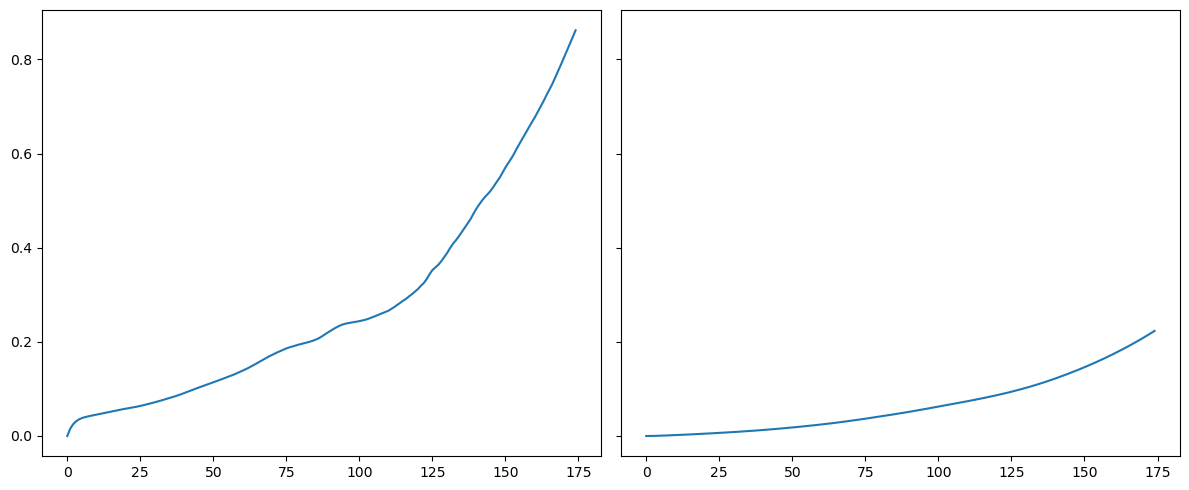

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax[0].plot(T1_ws)
ax[1].plot(T2_ws)

fig.tight_layout()
plt.show()

In [77]:
cases = {
    'no_geo': {'geo': False, 'ramp': None, 'T1': None, 'T2': None},
    'linear': {'geo': True, 'ramp': 'linear', 'T1': None, 'T2': None},
    'fast': {'geo': True, 'ramp': 'fast', 'T1': None, 'T2': None},
    'slow': {'geo': True, 'ramp': 'slow', 'T1': None, 'T2': None}
}

for case in cases:
    setup.sai_ramp = cases[case]['ramp']

    tmp_e = EmissionsBaseline(logs, setup, setup.tmin, 2100,
                              geo=cases[case]['geo'], Prior=Prior, Truth=Truth,
                              T_START=setup.tmin, T_END=setup.tmin + setup.nyrsramp,
                              print_level=1)

    logs.info(f"      >> The scenario created has geo flag as {tmp_e.geo} and the ramp is {tmp_e.sai_ramp}")

    cases[case]['T1'], cases[case]['T2'] = integrate_two_layer(tmp_e, Prior, setup.tmin, 2100, T_ics=[T1_ws[-1], T2_ws[-1]])

15:19:17 | INFO     |     > Emissions baseline for ssp245 created
15:19:17 | INFO     |       >> The scenario created has geo flag as False and the ramp is None
15:19:18 | INFO     |     > Emissions baseline for ssp245 created
15:19:18 | INFO     |       >> The scenario created has geo flag as True and the ramp is linear
15:19:19 | INFO     |     > Emissions baseline for ssp245 created
15:19:19 | INFO     |       >> The scenario created has geo flag as True and the ramp is fast
15:19:20 | INFO     |     > Emissions baseline for ssp245 created
15:19:20 | INFO     |       >> The scenario created has geo flag as True and the ramp is slow


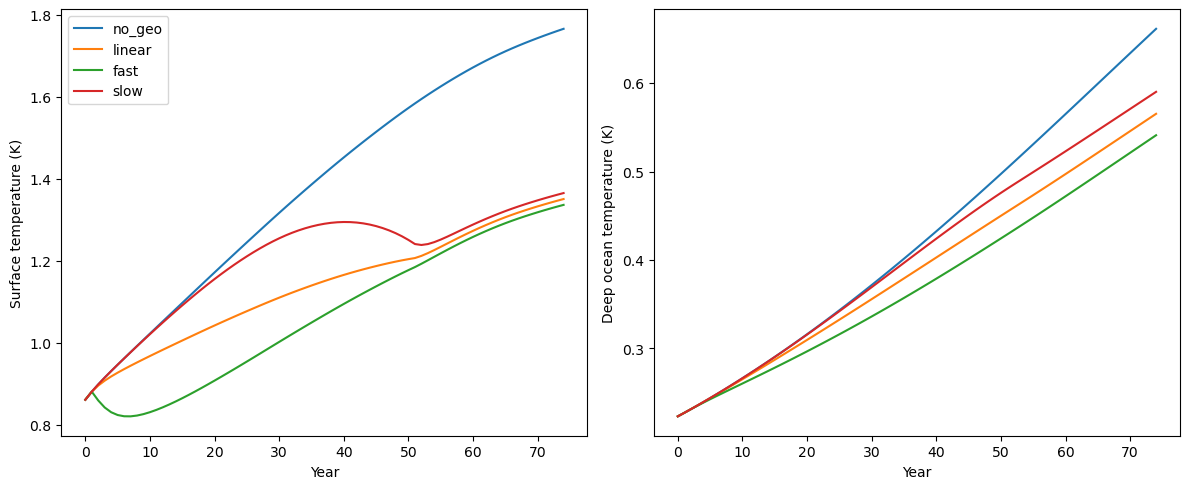

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for case in cases:
    ax[0].plot(cases[case]['T1'], label=case)
    ax[1].plot(cases[case]['T2'], label=case)

ax[0].legend()
ax[0].set_ylabel("Surface temperature (K)")

ax[1].set_ylabel("Deep ocean temperature (K)")

for i in range(2):
    ax[i].set_xlabel("Year")

fig.tight_layout()

plt.show()

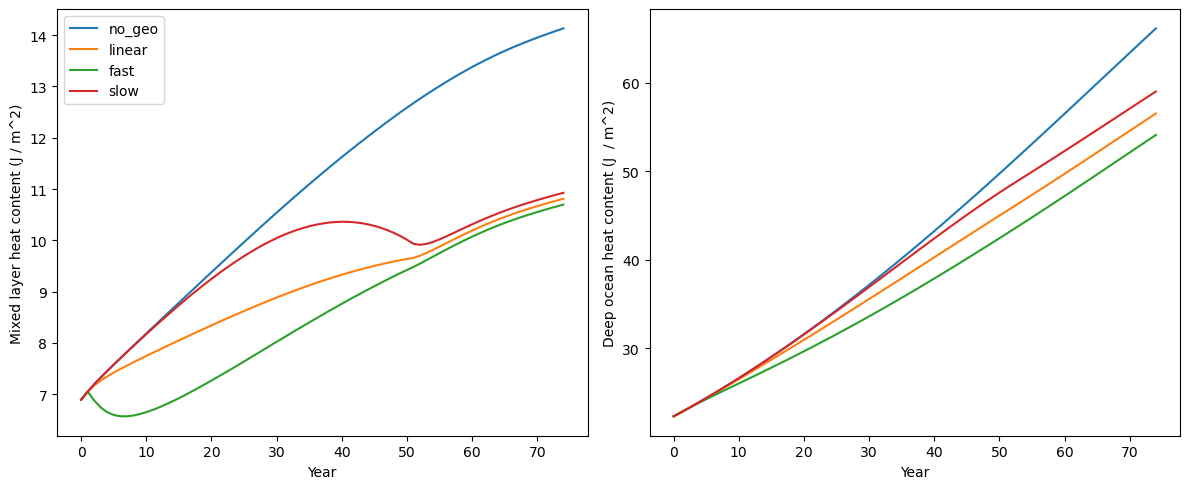

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for case in cases:
    ax[0].plot(Prior.C1_CEN * cases[case]['T1'], label=case)
    ax[1].plot(Prior.C2_CEN * cases[case]['T2'], label=case)

ax[0].legend()
ax[0].set_ylabel("Mixed layer heat content (J / m^2)")

ax[1].set_ylabel("Deep ocean heat content (J  / m^2)")

for i in range(2):
    ax[i].set_xlabel("Year")

fig.tight_layout()

plt.show()

In [87]:
geo_cases = ['linear', 'fast', 'slow']

for case in geo_cases:
    logs.info(f"For the {case} setup")
    logs.info(f"    > Difference in 2100 surface temperature: {cases['no_geo']['T1'][-1] - cases[case]['T1'][-1]}")
    logs.info(f"    > Difference in 2100 deep ocean temperature: {cases['no_geo']['T2'][-1] - cases[case]['T2'][-1]}")
    logs.info(f"    > Difference in 2100 surface heat content: {Prior.C1_CEN * cases['no_geo']['T1'][-1] - Prior.C1_CEN * cases[case]['T1'][-1]}")
    logs.info(f"    > Difference in 2100 deep ocean heat content: {Prior.C2_CEN * cases['no_geo']['T2'][-1] - Prior.C2_CEN * cases[case]['T2'][-1]}")


15:29:24 | INFO     | For the linear setup
15:29:24 | INFO     |     > Difference in 2100 surface temperature: 0.4151406281655363
15:29:24 | INFO     |     > Difference in 2100 deep ocean temperature: 0.09612079407227003
15:29:24 | INFO     |     > Difference in 2100 surface heat content: 3.3211250253242905
15:29:24 | INFO     |     > Difference in 2100 deep ocean heat content: 9.612079407227
15:29:24 | INFO     | For the fast setup
15:29:24 | INFO     |     > Difference in 2100 surface temperature: 0.42936338002122976
15:29:24 | INFO     |     > Difference in 2100 deep ocean temperature: 0.12035679235302499
15:29:24 | INFO     |     > Difference in 2100 surface heat content: 3.434907040169838
15:29:24 | INFO     |     > Difference in 2100 deep ocean heat content: 12.035679235302496
15:29:24 | INFO     | For the slow setup
15:29:24 | INFO     |     > Difference in 2100 surface temperature: 0.4005606092454119
15:29:24 | INFO     |     > Difference in 2100 deep ocean temperature: 0.07127

15:29:24 | INFO     |     > Difference in 2100 deep ocean heat content: 7.12761454924059
